# Experimental data

# 1. Calculating relative nucleation rates

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib.patches import Wedge

In [2]:
# Physical constants
PI = math.pi
KB = 8.617e-2  # Boltzmann constant, unit: eV/K

def nucleation_rate(surface_meta, n_meta, surface_stable, n_stable, delta_g_rxn, bulk_diff, temp):
    """
    Calculate the nucleation rate
    
    Parameters:
    -----------
    surface_meta : float
        Surface energy of metastable phase (eV/Å²)
    n_meta : float
        Number of atoms per unit volume in metastable phase (atoms/Å³)
    surface_stable : float
        Surface energy of stable phase (eV/Å²)
    n_stable : float
        Number of atoms per unit volume in stable phase (atoms/Å³)
    delta_g_rxn : float
        Reaction free energy change (eV/atom)
    bulk_diff : float
        Bulk energy difference (eV/atom)
    temp : float
        Temperature (K)
    
    Returns:
    --------
    rate : float
        Calculated nucleation rate
    """
    try:
        # First term
        term1 = surface_meta**3 / (n_meta**2 * (delta_g_rxn + bulk_diff)**2)
        
        # Second term
        term2 = surface_stable**3 / (n_stable**2 * delta_g_rxn**2)
        
        # Constant coefficient in exponent
        constant = (16 * PI) / (3 * KB * temp)
        
        # Exponent
        exponent = constant * (term1 - term2)
        
        # Nucleation rate
        rate = np.exp(exponent)
        
        return rate
        
    except ZeroDivisionError:
        raise ValueError("Division by zero: n_meta, n_stable, delta_g_rxn, or temp cannot be zero.")
    except Exception as e:
        raise ValueError(f"Unexpected error occurred: {e}")

In [92]:
temp = 550 + 273

# Surface energy
anatase_surface = 67.5 # J. Phys.: Condens. Matter 22 (2010) 175008
rutile_surface = 60.7 # Phys. Rev. B 90, 045304 (2014)
anatase_surface_wo = 58 # J. Chem. Theory Comput., Vol. 4, No. 2, 2008
rutile_surface_wo = 53 # J. Chem. Theory Comput., Vol. 4, No. 2, 2008

# Interface energy
inter_anatase_srtio3 = 15.9 # ACS Appl. Mater. Interfaces 2017, 9, 4106−4118
inter_rutile_srtio3 = 62.4 # ACS Appl. Mater. Interfaces 2017, 9, 4106−4118

# Vibrational energy difference
vib_E_diff_anatase_rutile = 5

# Strain energy difference
strain_anatase_rutile = 60  # ACS Appl. Mater. Interfaces 2017, 9, 4106−4118

# Desntiy
density_anatase = 0.0827428365678594
density_rutile = 0.09565606392434937

In [93]:
delta_g_rxn = np.arange(-600, -50, 1)


T_low  = 550  + 273 #℃
T_high = 1500 #K

lnJ_lowT_wo_sub = np.log(nucleation_rate(
    anatase_surface_wo, density_anatase,
    rutile_surface_wo, density_rutile,
    delta_g_rxn,
    vib_E_diff_anatase_rutile,
    T_low
))

lnJ_highT_wo_sub = np.log(nucleation_rate(
    anatase_surface_wo, density_anatase,
    rutile_surface_wo, density_rutile,
    delta_g_rxn,
    vib_E_diff_anatase_rutile,
    T_high
))

lnJ_lowT = np.log(nucleation_rate(
    anatase_surface + inter_anatase_srtio3, density_anatase,
    rutile_surface + inter_rutile_srtio3, density_rutile,
    delta_g_rxn,
    strain_anatase_rutile + vib_E_diff_anatase_rutile,
    T_low
))

lnJ_highT = np.log(nucleation_rate(
    anatase_surface + inter_anatase_srtio3, density_anatase,
    rutile_surface + inter_rutile_srtio3, density_rutile,
    delta_g_rxn,
    strain_anatase_rutile + vib_E_diff_anatase_rutile,
    T_high
))


C:\Users\NB\AppData\Local\Temp\ipykernel_17932\3951799056.py:45: RuntimeWarning: overflow encountered in exp
  rate = np.exp(exponent)
C:\Users\NB\AppData\Local\Temp\ipykernel_17932\3951799056.py:33: RuntimeWarning: divide by zero encountered in divide
  term1 = surface_meta**3 / (n_meta**2 * (delta_g_rxn + bulk_diff)**2)


In [94]:
# plt.plot(delta_g_rxn,lnJ_lowT_wo_sub)
# plt.plot(delta_g_rxn,lnJ_highT_wo_sub)

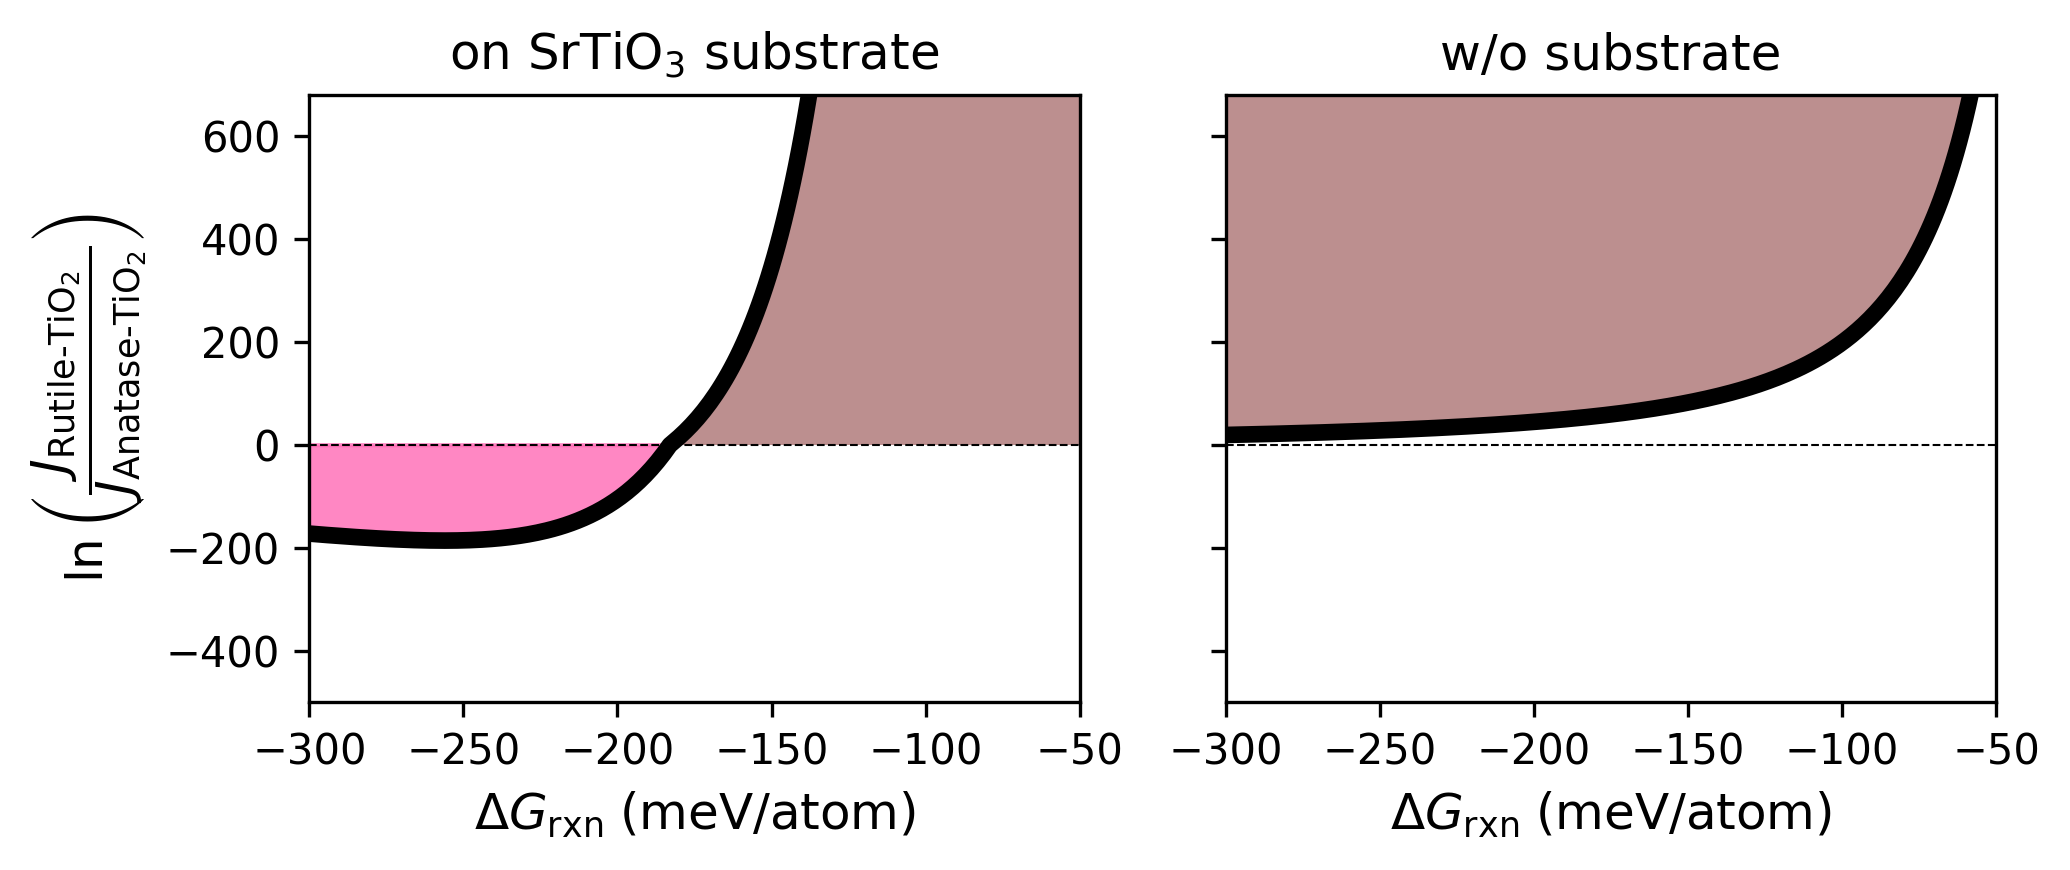

In [95]:

lw = 2
ls = 8


plt.figure(figsize=(7,3), dpi=300)


# ===================== (1) on SrTiO3 =====================
plt.subplot(1, 2, 1)
plt.title("on SrTiO$_3$ substrate")

plt.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
lnJ = lnJ_lowT.copy()
mask_pos = lnJ_lowT > 0
lnJ[mask_pos] = lnJ_highT[mask_pos]

plt.plot(delta_g_rxn, lnJ, color='black', linewidth=lw+2)

mask_pos = lnJ > 0
x_pos = delta_g_rxn[mask_pos]
y_pos = lnJ[mask_pos]

plt.fill_betweenx(y_pos, x_pos, x2=-50, color='rosybrown', alpha=1, label="Rutile growth")


# ===== Anatase growth fill=
delta_g_rxn2 = np.arange(-600, -180, 1)

lnJ_anatase = np.log(nucleation_rate(
    anatase_surface + inter_anatase_srtio3, density_anatase,
    rutile_surface + inter_rutile_srtio3, density_rutile,
    delta_g_rxn2,
    strain_anatase_rutile + vib_E_diff_anatase_rutile,
    T_low  
))


plt.fill_between(delta_g_rxn2, lnJ_anatase, color='hotpink', alpha=0.8, label="Anatase growth")

plt.tick_params(labelsize=ls+2)
plt.ylim(-500, 680)
plt.xlim(-300, -50)

plt.xlabel(r"$\Delta G_{\mathrm{rxn}}\;(\mathrm{meV}/\mathrm{atom})$", fontsize=ls+4)
plt.ylabel(
    r"$\ln \left(\dfrac{J_{\mathrm{Rutile\text{-}TiO_{2}}}}{J_{\mathrm{Anatase\text{-}TiO_{2}}}}\right)$",
    fontsize=ls+4
)


# ===================== (2) w/o substrate =====================
plt.subplot(1, 2, 2)
plt.title("w/o substrate")

plt.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
plt.plot(delta_g_rxn, lnJ_highT_wo_sub, color='black', linewidth=lw+2)

mask_positive_finite = (lnJ_highT_wo_sub >= 0) & np.isfinite(lnJ_highT_wo_sub)
lnJ_wo_for_fill = np.where(mask_positive_finite, lnJ_highT_wo_sub, 0)
plt.fill_between(delta_g_rxn, lnJ_wo_for_fill, 680, where=mask_positive_finite, 
                  color="rosybrown", interpolate=True)



plt.tick_params(labelsize=ls+2)
plt.ylim(-500, 680)
plt.xlim(-300, -50)

plt.xlabel(r"$\Delta G_{\mathrm{rxn}}\;(\mathrm{meV}/\mathrm{atom})$", fontsize=ls+4)
# plt.ylabel(
#     r"$\ln \left(\dfrac{J_{\mathrm{Rutile\text{-}TiO_{2}}}}{J_{\mathrm{Anatase\text{-}TiO_{2}}}}\right)$",
#     fontsize=ls+4
# )
plt.tick_params(axis='y', labelleft=False)

plt.tight_layout()

# 2. Reaction pathfindings 

In [6]:
import numpy as np
import collections


from pymatgen.entries.computed_entries import ComputedEntry
from rxn_network.entries.entry_set import GibbsEntrySet
from rxn_network.enumerators.basic import BasicEnumerator
from rxn_network.entries.interpolated import InterpolatedEntry
import pandas as pds


c:\Users\NB\anaconda3\envs\rxn3\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-09 19:21:52,318	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [7]:
# =============================================================================
# DFT-calculated Energies
# =============================================================================

### TDMAT ###

# Precursors
TDMAT = ComputedEntry("TiH24C8N4",-203.18095)

# Reactants
O2 = ComputedEntry("O2", -9.8799) 

# Target
TiO2 = ComputedEntry("Ti4O8",-107.29445)

# By-products
H2O = ComputedEntry("H2O", -14.233623)
CO2 = ComputedEntry("C2O4", -22.969825)
C2H4 = ComputedEntry("C2H4", -31.980520)
CH3 = ComputedEntry("CH3", -18.16748)
C2H5 = ComputedEntry("C2H5", -34.86254)
CH4 = ComputedEntry("CH4", -18.83721)
N2 = ComputedEntry("N2",-16.652252)
NH3 = ComputedEntry("NH3",-19.548272)
# N_CH3_2 = ComputedEntry("C2N1H6",-46.65391)

# Chemical potential of Ti
Ti = ComputedEntry("Ti3",-23.42342/3)


In [8]:
# =============================================================================
# DFT-calculated Energies
# =============================================================================

# Precursors
TTIP = ComputedEntry("TiH28C12O4",-252.21292)
TTIP_3 = ComputedEntry("TiH21C9O3",-190.19544)
TTIP_2 = ComputedEntry("TiH14C6O2",-127.66737)
TTIP_1 = ComputedEntry("TiH7C3O1",-64.81411)

# TiH3 = ComputedEntry("TiH3", -14.133337)

# Reactants
O2 = ComputedEntry("O2", -9.8799) 

# Target
TiO2 = ComputedEntry("Ti4O8",-107.29445)

# By-products
H2O = ComputedEntry("H2O", -14.233623)
CO2 = ComputedEntry("C2O4", -22.969825)
C2H4 = ComputedEntry("C2H4", -31.980520)
CH3 = ComputedEntry("CH3", -18.16748)
C2H5 = ComputedEntry("C2H5", -34.86254)
CH4 = ComputedEntry("CH4", -18.83721)
H2 = ComputedEntry("H2", -6.7903) 
# TiO4H4 = ComputedEntry("TiO4H4", -54.55249) 
OC3H7 = ComputedEntry("OC3H7", -57.82476) 
# Chemical potential of Ti
Ti = ComputedEntry("Ti3",-23.42342/3)


In [9]:
# =============================================================================
# Physical Constants
# =============================================================================
K_B = 1.380649e-23              # Boltzmann constant (J/K)
EV_PER_J = 1 / 1.60218e-19      # J to eV conversion
MOLAR_VOLUME_STP = 22414        # cm³/mol at STP


# =============================================================================
# Functions
# =============================================================================

def ideal_gas_entry(entry, T, P, P0=1.0):
    """
    Apply ideal gas correction: E_corrected = E + kT*ln(P/P0)
    
    Parameters:
    -----------
    entry : ComputedEntry
    T : float - Temperature (K)
    P : float - Pressure (atm)
    P0 : float - Reference pressure (atm), default=1.0
    
    Returns:
    --------
    ComputedEntry with corrected energy
    """
    kT_J = K_B * T
    correction_J = kT_J * np.log(P / P0)
    correction_eV = correction_J * EV_PER_J
    
    corrected_energy = entry.energy + correction_eV
    return ComputedEntry(entry.composition, corrected_energy)


def umol_per_min_to_sccm(flow_umol_min):
    """μmol/min -> SCCM"""
    return flow_umol_min * (MOLAR_VOLUME_STP / 1e6)

def mol_per_min_to_sccm(mol_per_min, stp_molar_volume_cm3=22414):
    """
    Convert mol/min to SCCM (Standard Cubic Centimeters per Minute).

    Parameters
    ----------
    mol_per_min : float
        Molar flow rate in mol/min.
    stp_molar_volume_cm3 : float, optional
        Molar volume at STP in cm^3/mol.
        Default is 22414 cm^3/mol (0 °C, 1 atm).

    Returns
    -------
    float
        Flow rate in SCCM.
    """
    sccm = mol_per_min * stp_molar_volume_cm3
    return sccm


In [10]:
# TDMAT condition
temp_TDMAT = 550+273
flow_TDMAT = mol_per_min_to_sccm(4*1e-7) #SCCM from mol/min
flow_O2_TDMAT = 70 #SCCM
flow_total_TDMAT = flow_TDMAT + flow_O2_TDMAT
P_chamber_TDMAT = 10 / 760 #atm (from 10 Torr)

pp_TDMAT = (flow_TDMAT / flow_total_TDMAT) * P_chamber_TDMAT
pp_O2_TDMAT = (flow_O2_TDMAT / flow_total_TDMAT) * P_chamber_TDMAT

ideal_TDMAT = ideal_gas_entry(TDMAT,temp_TDMAT,pp_TDMAT)
ideal_O2_TDMAT = ideal_gas_entry(O2,temp_TDMAT,pp_O2_TDMAT)



In [11]:
# TDMAT entries
TDMAT_entries = [ideal_TDMAT,ideal_O2_TDMAT,TiO2,H2O,CO2,C2H4,CH3,C2H5,CH4,N2,NH3,H2]
TDMAT_entries_inter = []
for entry in TDMAT_entries:
    TDMAT_entry_inter = InterpolatedEntry(entry.composition, entry.energy)
    TDMAT_entries_inter.append(TDMAT_entry_inter)
TDMAT_gibbs_entries = GibbsEntrySet(entries=TDMAT_entries_inter)

In [12]:
# TDMAT reactions

be_TDMAT = BasicEnumerator(n=4,precursors=[ideal_TDMAT.composition,
                                        ideal_O2_TDMAT.composition],
                        targets=["TiO2"])
rxns_TDMAT = be_TDMAT.enumerate(TDMAT_gibbs_entries)

2026-02-09 19:21:57,084 INFO rxn_network.utils.ray Ray is not initialized. Checking for existing cluster...
2026-02-09 19:21:57,086 INFO rxn_network.utils.ray Could not identify existing Ray instance. Creating a new one...


2026-02-09 19:21:59,611	INFO worker.py:2013 -- Started a local Ray instance.


2026-02-09 19:22:02,451 INFO rxn_network.utils.ray HOST: DESKTOP-9NR7JST, Num CPUs: 8.0, Total Memory: 4282068583.0


c:\Users\NB\anaconda3\envs\rxn3\lib\site-packages\ray\_private\worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
Enumerating reactions (BasicEnumerator): 100%|██████████| 20/20 [00:08<00:00,  2.27it/s]


In [13]:
len(rxns_TDMAT)

18

In [14]:
# TTIP condition
temp_TTIP = 1500 # test
pp_TTIP = 0.4 / 101.3 # atm from 0.4 kpa

ideal_TTIP = ideal_gas_entry(TTIP,temp_TTIP,pp_TTIP)
ideal_TTIP_3 = ideal_gas_entry(TTIP_3,temp_TTIP,pp_TTIP)
ideal_TTIP_2 = ideal_gas_entry(TTIP_2,temp_TTIP,pp_TTIP)
ideal_TTIP_1 = ideal_gas_entry(TTIP_1,temp_TTIP,pp_TTIP)

# ideal_TiH3 = ideal_gas_entry(TiH3,temp_TTIP,pp_TTIP)
ideal_O2_TTIP = ideal_gas_entry(O2,temp_TTIP,pp_TTIP)


In [15]:
# TTIP entries
# TTIP_entries = [ideal_TTIP,ideal_TTIP_3,ideal_TTIP_2,TiO2,ideal_TTIP_1,ideal_O2_TTIP,ideal_TiH3,H2O,CO2,C2H4,CH3,C2H5,CH4,H2]
TTIP_entries = [ideal_TTIP,ideal_TTIP_3,ideal_TTIP_2,TiO2,ideal_TTIP_1,ideal_O2_TTIP,H2O,CO2,C2H4,CH3,C2H5,CH4,H2,OC3H7]

TTIP_entries_inter = []

for entry in TTIP_entries:
    TTIP_entry_inter = InterpolatedEntry(entry.composition, entry.energy)
    TTIP_entries_inter.append(TTIP_entry_inter)

TTIP_gibbs_entries = GibbsEntrySet(entries=TTIP_entries_inter)

In [18]:
# TTIP reactions

be_TTIP = BasicEnumerator(n=3,precursors=[ideal_TTIP.composition,
                                          ideal_TTIP_3.composition,
                                          ideal_TTIP_2.composition,
                                          ideal_TTIP_1.composition,
                                          ideal_O2_TTIP.composition],
                        targets=["TiO2"])
rxns_TTIP = be_TTIP.enumerate(TTIP_gibbs_entries)

Enumerating reactions (BasicEnumerator): 100%|██████████| 24/24 [00:00<00:00, 28.30it/s]


In [19]:
len(rxns_TTIP)

52

In [20]:
all_rows = []   

# ===== TDMAT reactions =====
for rxn in rxns_TDMAT:
    Grxn = round(rxn.energy_per_atom * 1000, 2)

    by_products = []
    for product in rxn.products:
        if product != TiO2.composition:
            by_products.append(product.reduced_formula)

    all_rows.append({
        "Precursor": "TDMAT",
        "Reactant": "O2",
        "By-products": ', '.join(str(p) for p in by_products),
        "ΔG_rxn (meV/atom)": Grxn,
        "rxn": rxn
    })


# ===== TTIP reactions =====
for rxn in rxns_TTIP:
    Grxn = round(rxn.energy_per_atom * 1000, 2)

    by_products = []
    for product in rxn.products:
        if product != TiO2.composition:
            by_products.append(product.reduced_formula)

    all_rows.append({
        "Precursor": "TTIP",
        "Reactant": "X",
        "By-products": ', '.join(str(p) for p in by_products),
        "ΔG_rxn (meV/atom)": Grxn,
        "rxn": rxn
    })

In [59]:
df_rxn = pds.DataFrame(
    all_rows,
    columns=[
        "Precursor",
        "Reactant",
        "By-products",
        "ΔG_rxn (meV/atom)",
        "rxn"
    ]
)

df_rxn = df_rxn.sort_values(
    ["ΔG_rxn (meV/atom)"]
).reset_index(drop=True)

df_rxn.insert(0, "Reaction", range(1, len(df_rxn) + 1))
df_rxn

,Reaction,Precursor,Reactant,By-products,ΔG_rxn (meV/atom),rxn
0,1,TTIP,X,"TiO2, TiH28(C3O)4",-731.40,TiH7C3O + 0.75 O2 -> 0.75 TiO2 + 0.25 TiH28(C3O)4
1,2,TTIP,X,"TiH21(C3O)3, TiO2",-669.48,O2 + 1.5 TiH7C3O -> 0.5 TiH21(C3O)3 + TiO2
2,3,TTIP,X,"TiO2, H2O, H2C",-624.83,TiH7C3O + 0.75 O2 -> TiO2 + 0.5 H2O + 3 H2C
3,4,TTIP,X,"TiO2, H7C3O",-608.83,TiH7C3O + O2 -> TiO2 + H7C3O
4,5,TTIP,X,"TiO2, H2, H2C",-566.34,TiH7C3O + 0.5 O2 -> TiO2 + 0.5 H2 + 3 H2C
...,...,...,...,...,...,...
65,66,TTIP,X,"TiO2, H2, CO2",1391.12,TiH14(C3O)2 + 6 O2 -> TiO2 + 7 H2 + 6 CO2
66,67,TTIP,X,"TiO2, H4C, CO2",1396.50,3.25 O2 + TiH21(C3O)3 -> TiO2 + 5.25 H4C + 3.7...
67,68,TTIP,X,"TiO2, CO2, H4C",1494.35,TiH28(C3O)4 + 4 O2 -> TiO2 + 5 CO2 + 7 H4C
68,69,TTIP,X,"TiO2, CO2, H2",1558.52,8.5 O2 + TiH21(C3O)3 -> TiO2 + 9 CO2 + 10.5 H2


In [60]:
# Filtering ΔG_rxn (meV/atom) range from -65 to -20 meV/atom
filtered_df = df_rxn[(df_rxn['ΔG_rxn (meV/atom)'] >= -240) & (df_rxn['ΔG_rxn (meV/atom)'] <= -130)]
filtered_df

,Reaction,Precursor,Reactant,By-products,ΔG_rxn (meV/atom),rxn
11,12,TDMAT,O2,"N2, H2O, H2C, TiO2",-239.53,0.5 TiH24(C2N)4 + 1.5 O2 -> N2 + 2 H2O + 4 H2C...
12,13,TTIP,X,"TiO2, TiH21(C3O)3",-181.71,3 TiH14(C3O)2 + O2 -> TiO2 + 2 TiH21(C3O)3
13,14,TTIP,X,"TiO2, H7C3O",-139.80,TiH14(C3O)2 + O2 -> TiO2 + 2 H7C3O
14,15,TTIP,X,"TiO2, H2C, H2O",-138.27,TiH14(C3O)2 + 0.5 O2 -> TiO2 + 6 H2C + H2O


In [61]:
rxn_TDMAT = filtered_df.loc[filtered_df["Reaction"] == 12, "ΔG_rxn (meV/atom)"].values[0]
rxn_TTIP = filtered_df.loc[filtered_df["Reaction"] == 14, "ΔG_rxn (meV/atom)"].values[0]


In [64]:
aa_TDMAT = filtered_df.loc[filtered_df["Reaction"] == 12, "rxn"].values[0]
aa_TDMAT

0.5 TiH24(C2N)4 + 1.5 O2 -> N2 + 2 H2O + 4 H2C + 0.5 TiO2

In [31]:
lnJ_TDMAT = np.log(nucleation_rate(
    anatase_surface + inter_anatase_srtio3, density_anatase,
    rutile_surface + inter_rutile_srtio3, density_rutile,
    rxn_TDMAT,
    strain_anatase_rutile + vib_E_diff_anatase_rutile,
    T_low))

lnJ_TTIP = np.log(nucleation_rate(
    anatase_surface + inter_anatase_srtio3, density_anatase,
    rutile_surface + inter_rutile_srtio3, density_rutile,
    rxn_TTIP,
    strain_anatase_rutile + vib_E_diff_anatase_rutile,
    T_high
))

Text(0, 0.5, '$\\ln \\left(\\dfrac{J_{\\mathrm{Rutile\\text{-}TiO_{2}}}}{J_{\\mathrm{Anatase\\text{-}TiO_{2}}}}\\right)$')

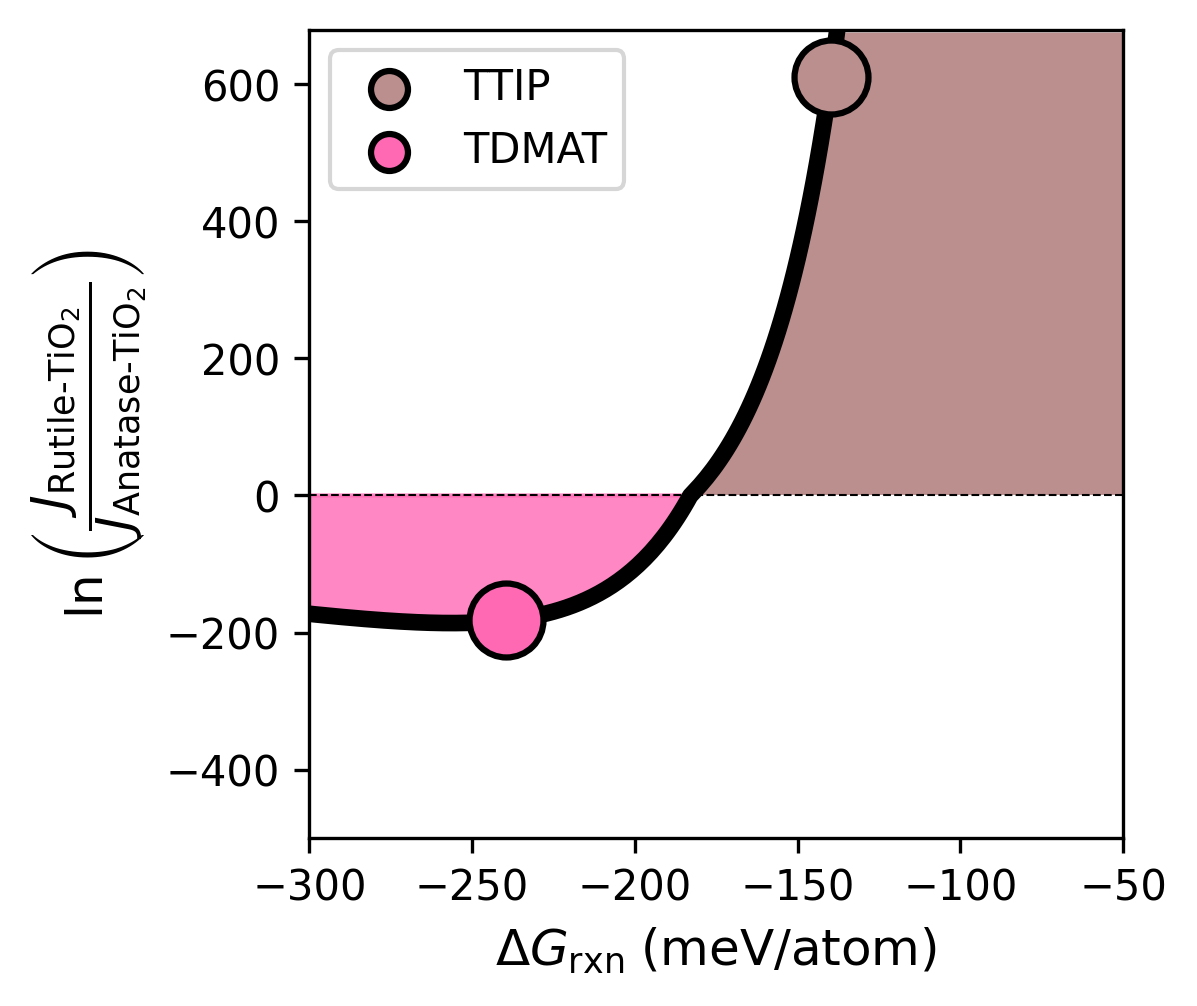

In [57]:
delta_g_rxn = np.arange(-600, -100, 1)

lw = 2
ls = 8

T_low  = 550  + 273
T_high = 1500

plt.figure(figsize=(3.5, 3.5), dpi=300)
plt.axhline(y=0, color='k', linestyle='--', linewidth=0.5)

plt.plot(delta_g_rxn, lnJ, color='black', linewidth=lw+2,zorder=2)

mask_pos = lnJ > 0

mask_pos = lnJ > 0
x_pos = delta_g_rxn[mask_pos]
y_pos = lnJ[mask_pos]

plt.fill_betweenx(y_pos, x_pos, x2=-50, color='rosybrown', alpha=1,zorder=1)

# ===== Anatase growth fill=
delta_g_rxn2 = np.arange(-600, -180, 1)


plt.fill_between(delta_g_rxn2, lnJ_anatase, color='hotpink', alpha=0.8, zorder=1)
s = 315
plt.scatter(rxn_TTIP,lnJ_TTIP,zorder=3,s=315, edgecolors='k',linewidths=1.5,color='rosybrown',label="TTIP")

plt.scatter(rxn_TDMAT,lnJ_TDMAT,zorder=3,s=315, edgecolors='k',linewidths=1.5,color='hotpink',label="TDMAT")
plt.legend(markerscale=0.5)
plt.tick_params(labelsize=ls+2)
plt.ylim(-500, 680)
plt.xlim(-300, -50)

plt.xlabel(r"$\Delta G_{\mathrm{rxn}}\;(\mathrm{meV}/\mathrm{atom})$", fontsize=ls+4)
plt.ylabel(
    r"$\ln \left(\dfrac{J_{\mathrm{Rutile\text{-}TiO_{2}}}}{J_{\mathrm{Anatase\text{-}TiO_{2}}}}\right)$",
    fontsize=ls+4
)